In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


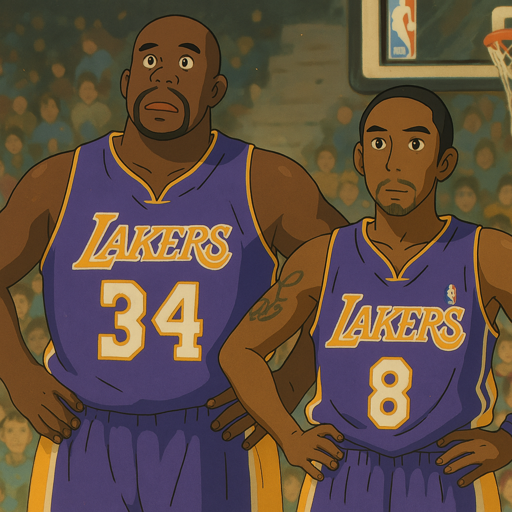

In [34]:
from PIL import Image
image_colored = Image . open ("/content/drive/MyDrive/AI_and_ML/week1/kobshq.png")
image_colored = image_colored . resize (( 512 , 512 ))

display ( image_colored)

In [35]:
import numpy as np
import matplotlib . pyplot as plt
from PIL import Image
# Load image and convert to grayscale
image = Image . open ("/content/drive/MyDrive/AI_and_ML/week1/kobshq.png") . convert ("L")
# Convert to NumPy array
image_array = np . array ( image )
# Get image dimensions
height , width = image_array . shape
# Reshape the image into a 2D array where each row represents a row of pixels
# This allows PCA to process each row as an observation and find patterns across pixel intensities
data = image_array . reshape ( height , width )

In [36]:
# Compute the mean of each column ( feature )
mean = np . mean ( data , axis =0)
# Subtract mean to center the data
centered_data = data - mean# Compute the mean of each column ( feature )
mean = np . mean ( data , axis =0)
# Subtract mean to center the data
centered_data = data - mean

In [37]:
# Compute covariance matrix
cov_matrix = np . cov ( centered_data , rowvar = False )

In [38]:
# Compute eigenvalues and eigenvectors
eigenvalues , eigenvectors = np . linalg . eigh ( cov_matrix )
# Sort eigenvalues and corresponding eigenvectors indescending order
sorted_indices = np . argsort ( eigenvalues ) [:: -1]
eigenvalues = eigenvalues [ sorted_indices ]
eigenvectors = eigenvectors [: , sorted_indices ]

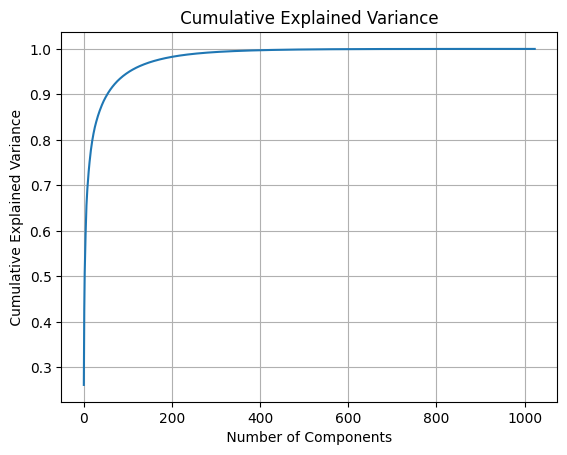

In [39]:
# Plot the explained variance ratio
explained_variance_ratio = eigenvalues / np .sum ( eigenvalues )
plt . plot ( np . cumsum ( explained_variance_ratio ) )
plt . title (" Cumulative Explained Variance ")
plt . xlabel (" Number of Components ")
plt . ylabel (" Cumulative Explained Variance ")
plt . grid ( True )
plt . show ()

In [40]:
k = 50 # Choose k principal components
components = eigenvectors [: , : k ]

In [41]:
# Project the data onto the principal components
compressed_data = np . dot ( centered_data , components )

In [42]:
# Reconstruct the image from compressed data
decompressed_data = np . dot ( compressed_data , components . T ) + mean

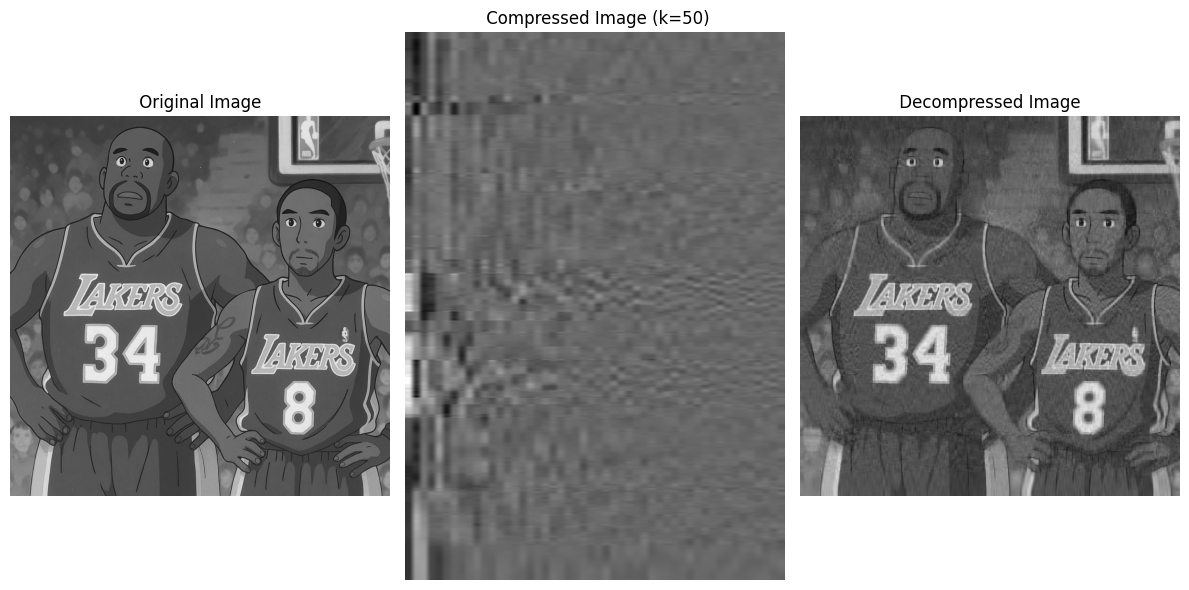

In [43]:
plt . figure ( figsize =(12 , 6) )
# Original Image
plt . subplot (1 , 3 , 1)
plt . imshow ( image_array , cmap ="gray")
plt . title (" Original Image ")
plt . axis ("off")
# Compressed Representation
plt . subplot (1 , 3 , 2)
plt . imshow ( compressed_data , cmap ="gray", aspect ="auto")
plt . title ( f" Compressed Image (k={k})")
plt . axis ("off")
# Decompressed Image
plt . subplot (1 , 3 , 3)
plt . imshow ( decompressed_data , cmap ="gray")
plt . title (" Decompressed Image ")
plt . axis ("off")
plt . tight_layout ()
plt . show ()

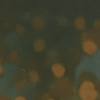

In [46]:
# Define the cropping box (left, upper, right, lower)
left = 0
upper = 0
right = 100
lower = 100

# Crop the image (assign the result!)
cropped_image = image_colored.crop((left, upper, right, lower))

# Display the cropped image
display(cropped_image)

In [47]:
import numpy as np
# Convert the Pillow image to a NumPy array
image_array_colored = np . array ( image_colored )
# Display the shape of the NumPy array (height , width , channels )
print (" Shape of the image array :", image_array_colored .shape )

 Shape of the image array : (512, 512, 3)


 Shape of the image array : (512, 512, 3)


array([[[ 52,   0,   0],
        [ 52,   0,   0],
        [ 52,   0,   0],
        ...,
        [ 67,   0,   0],
        [ 68,   0,   0],
        [ 68,   0,   0]],

       [[ 50,   0,   0],
        [ 52,   0,   0],
        [ 54,   0,   0],
        ...,
        [ 69,   0,   0],
        [ 69,   0,   0],
        [ 69,   0,   0]],

       [[ 53,   0,   0],
        [ 53,   0,   0],
        [ 53,   0,   0],
        ...,
        [ 68,   0,   0],
        [ 68,   0,   0],
        [ 70,   0,   0]],

       ...,

       [[139,   0,   0],
        [132,   0,   0],
        [127,   0,   0],
        ...,
        [112,   0,   0],
        [113,   0,   0],
        [116,   0,   0]],

       [[139,   0,   0],
        [137,   0,   0],
        [129,   0,   0],
        ...,
        [112,   0,   0],
        [113,   0,   0],
        [115,   0,   0]],

       [[138,   0,   0],
        [135,   0,   0],
        [133,   0,   0],
        ...,
        [110,   0,   0],
        [110,   0,   0],
        [114,   0,   0]]], dtype=uint8)
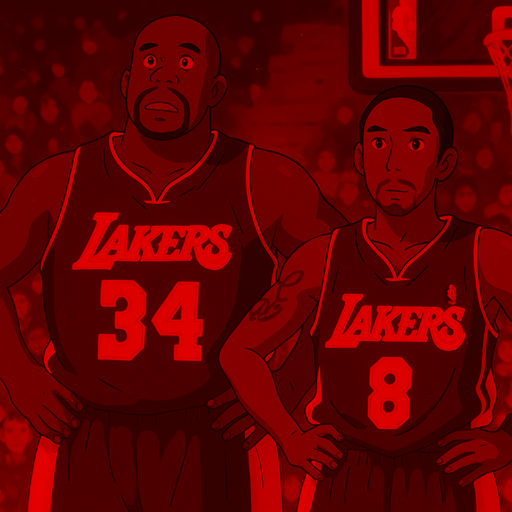

In [48]:
# Convert the Pillow image to a NumPy array
image_array_colored = np . array ( image_colored )
# Display the shape of the NumPy array (height , width ,channels )
print (" Shape of the image array :", image_array_colored . shape)
#For Red Channels
red_channel = image_array_colored.copy() # Red channel
red_channel [: , : , 1]= 0 # Green channel
red_channel [: , : , 2]= 0
display (red_channel)


array([[[ 0,  0, 41],
        [ 0,  0, 42],
        [ 0,  0, 41],
        ...,
        [ 0,  0, 54],
        [ 0,  0, 55],
        [ 0,  0, 54]],

       [[ 0,  0, 40],
        [ 0,  0, 41],
        [ 0,  0, 42],
        ...,
        [ 0,  0, 55],
        [ 0,  0, 56],
        [ 0,  0, 55]],

       [[ 0,  0, 42],
        [ 0,  0, 42],
        [ 0,  0, 41],
        ...,
        [ 0,  0, 54],
        [ 0,  0, 54],
        [ 0,  0, 55]],

       ...,

       [[ 0,  0, 67],
        [ 0,  0, 64],
        [ 0,  0, 68],
        ...,
        [ 0,  0, 82],
        [ 0,  0, 80],
        [ 0,  0, 79]],

       [[ 0,  0, 65],
        [ 0,  0, 65],
        [ 0,  0, 63],
        ...,
        [ 0,  0, 84],
        [ 0,  0, 84],
        [ 0,  0, 85]],

       [[ 0,  0, 64],
        [ 0,  0, 62],
        [ 0,  0, 63],
        ...,
        [ 0,  0, 84],
        [ 0,  0, 85],
        [ 0,  0, 86]]], dtype=uint8)
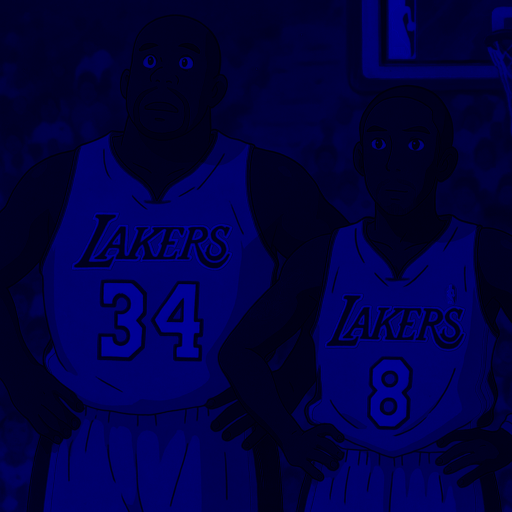

In [49]:
# For Blue Channel :
blue_channel = image_array_colored.copy() # Blue channel
blue_channel [: , : , 0]=0 # red channel
blue_channel [: , : , 1]=0 # green channel


display ( blue_channel )

array([[[  0,  55,   0],
        [  0,  56,   0],
        [  0,  56,   0],
        ...,
        [  0,  74,   0],
        [  0,  74,   0],
        [  0,  74,   0]],

       [[  0,  55,   0],
        [  0,  56,   0],
        [  0,  58,   0],
        ...,
        [  0,  75,   0],
        [  0,  76,   0],
        [  0,  76,   0]],

       [[  0,  56,   0],
        [  0,  56,   0],
        [  0,  55,   0],
        ...,
        [  0,  76,   0],
        [  0,  75,   0],
        [  0,  76,   0]],

       ...,

       [[  0, 124,   0],
        [  0, 119,   0],
        [  0, 120,   0],
        ...,
        [  0, 117,   0],
        [  0, 117,   0],
        [  0, 120,   0]],

       [[  0, 122,   0],
        [  0, 122,   0],
        [  0, 116,   0],
        ...,
        [  0, 118,   0],
        [  0, 120,   0],
        [  0, 121,   0]],

       [[  0, 120,   0],
        [  0, 119,   0],
        [  0, 118,   0],
        ...,
        [  0, 118,   0],
        [  0, 118,   0],
        [  0, 121,   0]]], dtype=uint8)
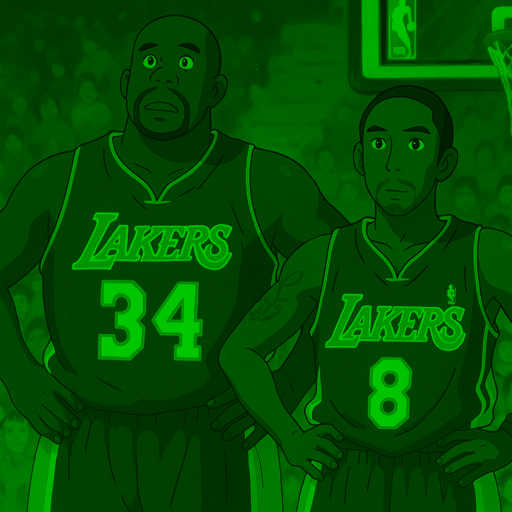

In [50]:
# For Blue Channel :
green_channel = image_array_colored.copy() # Blue channel
green_channel [: , : , 0]=0 # red channel
green_channel [: , : , 2]=0 # blue channel


display ( green_channel )

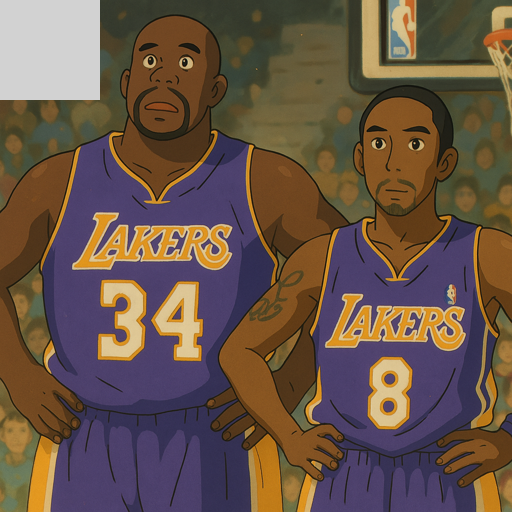

In [51]:
import numpy as np
from PIL import Image

# Convert the colored image to a NumPy array
modified_image_array = np.array(image_colored)

# Modify the top-left 100x100 pixels to a value of 210
# For an RGB image, we need to set all three channels (R, G, B) to 210
modified_image_array[0:100, 0:100, :] = 210

# Convert the NumPy array back to a PIL Image
modified_image = Image.fromarray(modified_image_array)

# Display the modified image
display(modified_image)